# Simulated muon overburden scan

Compare Geant4 detector outputs for rock thicknesses from 0 to 1000 m. Each simulation contains 50,000 generated primaries.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'muography').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from muography.dataio import parse_paul_dat
from muography.events import group_events
from muography.tracking import reconstruct_track

OUTPUT_DIR = PROJECT_ROOT / 'muon-sim' / 'output'
FIG_DIR = PROJECT_ROOT / 'analysis' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
N_PRIMARIES = 50_000
depths_m = np.array([0, 100, 250, 500, 750, 1000])

In [2]:
n_detected = []
theta_by_depth = {}

for depth in depths_m:
    rows = parse_paul_dat(OUTPUT_DIR / f'depth_{depth}m.dat')
    events = group_events(rows)
    n_detected.append(len(events))

    theta_by_depth[depth] = np.asarray([
        track['theta_deg']
        for event in events
        if (track := reconstruct_track(event)) is not None
    ])

n_detected = np.asarray(n_detected)
acceptance = n_detected / N_PRIMARIES
transmission = acceptance / acceptance[0]

for depth, count, acc, trans in zip(depths_m, n_detected, acceptance, transmission):
    print(f'{depth:4d} m: {count:6d} detected | acceptance={acc:.5f} | transmission={trans:.5f}')

   0 m:    739 detected | acceptance=0.01478 | transmission=1.00000
 100 m:      0 detected | acceptance=0.00000 | transmission=0.00000
 250 m:      0 detected | acceptance=0.00000 | transmission=0.00000
 500 m:      0 detected | acceptance=0.00000 | transmission=0.00000
 750 m:      0 detected | acceptance=0.00000 | transmission=0.00000
1000 m:      0 detected | acceptance=0.00000 | transmission=0.00000


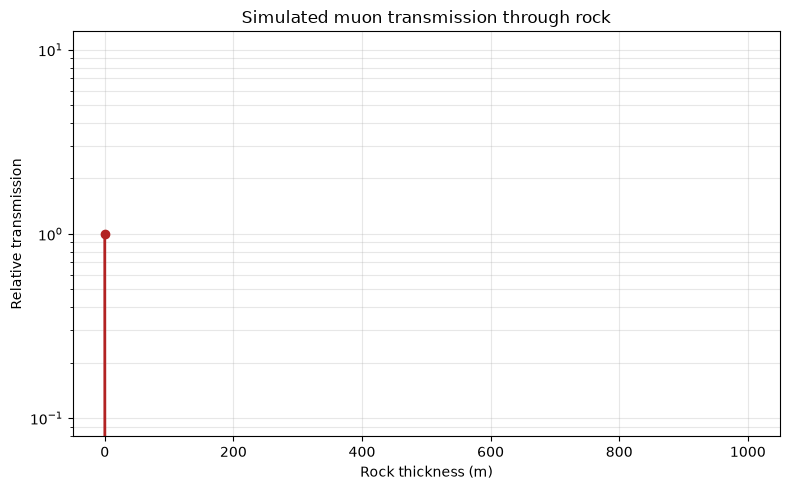

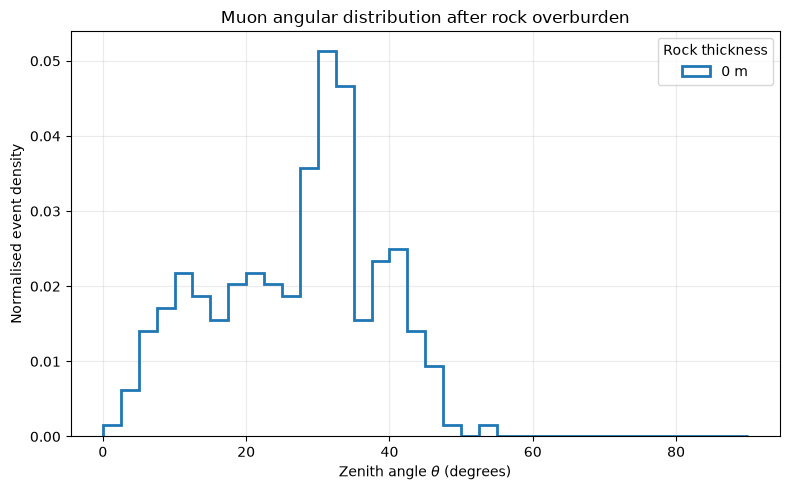

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(depths_m, transmission, 'o-', lw=2, color='firebrick')
ax.set(xlabel='Rock thickness (m)', ylabel='Relative transmission',
       title='Simulated muon transmission through rock')
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'simulated_depth_transmission.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for depth in depths_m:
    theta = theta_by_depth[depth]
    if len(theta):
        ax.hist(theta, bins=np.linspace(0, 90, 37), histtype='step',
                linewidth=2, density=True, label=f'{depth} m')
ax.set(xlabel=r'Zenith angle $\theta$ (degrees)', ylabel='Normalised event density',
       title='Muon angular distribution after rock overburden')
ax.legend(title='Rock thickness')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / 'simulated_angular_by_depth.png', dpi=160)
plt.show()